Data loaded successfully
✅ Model trained successfully
Accuracy: 0.86875

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.86      0.87       160
           1       0.86      0.88      0.87       160

    accuracy                           0.87       320
   macro avg       0.87      0.87      0.87       320
weighted avg       0.87      0.87      0.87       320



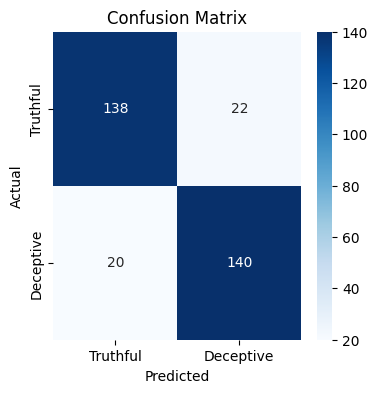

✅ Model saved as review_model.pkl


In [1]:
# ==============================
# ReviewGuard: Model Training
# ==============================

import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ==============================
# 1️⃣ Load Preprocessed Data
# ==============================

X_train = joblib.load("../models/X_train.pkl")
X_test = joblib.load("../models/X_test.pkl")
y_train = joblib.load("../models/y_train.pkl")
y_test = joblib.load("../models/y_test.pkl")

print("Data loaded successfully")

# ==============================
# 2️⃣ Train Model
# ==============================

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("✅ Model trained successfully")


# ==============================
# 3️⃣ Evaluate Model
# ==============================

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# ==============================
# 4️⃣ Confusion Matrix
# ==============================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Truthful", "Deceptive"],
            yticklabels=["Truthful", "Deceptive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ==============================
# 5️⃣ Save Model
# ==============================

os.makedirs("../models", exist_ok=True)
joblib.dump(model, "../models/review_model.pkl")

print("✅ Model saved as review_model.pkl")

